# Task 3.2 (c) — Algorithm Comparison and Winner Selection

This notebook loads the results from notebooks 3a (default-HP baseline) and 3b (full rnCV), produces the comparison tables and figures required for the report, and identifies the **winning algorithm** with statistical justification.

**Winner-selection criterion:**
1. Rank algorithms by **median MCC** across the 50 outer-test scores (5 folds × 10 reps).
2. If the top algorithms have overlapping 95% bootstrap confidence intervals on the median, treat them as statistically tied.
3. Break ties by considering the median **AUC** and **PR-AUC** — clinically important secondary metrics.
4. As a final tiebreaker, prefer algorithms with simpler models and faster training (deployment considerations).

**Why MCC as the primary criterion?** MCC is a single number that takes into account all four cells of the confusion matrix, is symmetric in the two classes, and gives a balanced summary even under class imbalance.

In [1]:
# ── Setup ────
import sys, pickle, os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import bootstrap_median_ci, METRIC_NAMES

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Results from Notebooks 3a and 3b

In [2]:
# ── Load pickles ─────────────────────────────────────────────────────────────
with open('../results/baseline_results.pkl', 'rb') as f:
    baseline = pickle.load(f)
with open('../results/rncv_results.pkl', 'rb') as f:
    rncv     = pickle.load(f)

baseline_df = baseline['results']
rncv_df     = rncv['results']

print(f'Baseline results: {baseline_df.shape}  (algorithms: {baseline_df["algorithm"].nunique()})')
print(f'rnCV results:     {rncv_df.shape}  (algorithms: {rncv_df["algorithm"].nunique()})')
print(f'\nBaseline runtime: {baseline["runtime_seconds"]/60:.1f} min')
print(f'rnCV runtime:     {rncv["runtime_seconds"]/60:.1f} min')

Baseline results: (350, 11)  (algorithms: 7)
rnCV results:     (350, 11)  (algorithms: 7)

Baseline runtime: 0.4 min
rnCV runtime:     60.4 min


## 2. Side-by-Side Summary Table

We make a chart of the median and 95% bootstrap CI for each algorithm under both conditions (default vs. tuned).

In [3]:
# ── Build comparison table ─────
key_metrics = ['mcc', 'auc', 'pr_auc', 'balanced_acc', 'f1', 'recall', 'specificity', 'precision']

def summarize(df, algos):
    rows = []
    for algo in algos:
        sub = df[df['algorithm'] == algo]
        row = {'algorithm': algo}
        for m in key_metrics:
            med, lo, hi = bootstrap_median_ci(sub[m].to_numpy(), seed=42)
            row[m] = (med, lo, hi)
        rows.append(row)
    return pd.DataFrame(rows).set_index('algorithm')

algos = baseline_df['algorithm'].unique()
baseline_tab = summarize(baseline_df, algos)
rncv_tab     = summarize(rncv_df, algos)

# 'median [lo, hi]' strings for display
def fmt(triple):
    m, lo, hi = triple
    return f'{m:.3f} [{lo:.3f}, {hi:.3f}]'

print('═' * 100)
print('DEFAULT HYPERPARAMETERS (baseline)')
print('═' * 100)
display(baseline_tab.applymap(fmt))

print('═' * 100)
print('TUNED HYPERPARAMETERS (rnCV)')
print('═' * 100)
display(rncv_tab.applymap(fmt))

════════════════════════════════════════════════════════════════════════════════════════════════════
DEFAULT HYPERPARAMETERS (baseline)
════════════════════════════════════════════════════════════════════════════════════════════════════


,mcc,auc,pr_auc,balanced_acc,f1,recall,specificity,precision
algorithm,,,,,,,,
LogisticRegression,"0.640 [0.590, 0.678]","0.892 [0.876, 0.906]","0.893 [0.866, 0.912]","0.815 [0.794, 0.833]","0.791 [0.776, 0.816]","0.773 [0.727, 0.818]","0.885 [0.846, 0.885]","0.842 [0.800, 0.857]"
GaussianNB,"0.642 [0.607, 0.687]","0.892 [0.878, 0.907]","0.886 [0.860, 0.901]","0.817 [0.798, 0.842]","0.800 [0.773, 0.828]","0.778 [0.739, 0.818]","0.846 [0.846, 0.885]","0.833 [0.800, 0.857]"
LDA,"0.667 [0.628, 0.707]","0.897 [0.881, 0.911]","0.897 [0.874, 0.911]","0.823 [0.809, 0.849]","0.809 [0.780, 0.829]","0.773 [0.727, 0.818]","0.885 [0.852, 0.923]","0.857 [0.826, 0.878]"
RandomForest,"0.590 [0.577, 0.624]","0.878 [0.864, 0.901]","0.876 [0.861, 0.896]","0.794 [0.779, 0.809]","0.774 [0.756, 0.787]","0.733 [0.696, 0.773]","0.846 [0.830, 0.885]","0.809 [0.783, 0.828]"
LightGBM,"0.553 [0.538, 0.590]","0.856 [0.837, 0.866]","0.860 [0.833, 0.871]","0.775 [0.766, 0.793]","0.750 [0.739, 0.773]","0.727 [0.696, 0.773]","0.811 [0.793, 0.849]","0.786 [0.750, 0.805]"
XGBoost,"0.569 [0.523, 0.593]","0.859 [0.837, 0.876]","0.860 [0.844, 0.871]","0.779 [0.759, 0.796]","0.758 [0.744, 0.783]","0.773 [0.739, 0.795]","0.808 [0.769, 0.846]","0.773 [0.741, 0.796]"
CatBoost,"0.588 [0.550, 0.626]","0.877 [0.865, 0.892]","0.875 [0.865, 0.906]","0.787 [0.774, 0.809]","0.769 [0.747, 0.785]","0.756 [0.727, 0.818]","0.846 [0.808, 0.885]","0.800 [0.773, 0.833]"


════════════════════════════════════════════════════════════════════════════════════════════════════
TUNED HYPERPARAMETERS (rnCV)
════════════════════════════════════════════════════════════════════════════════════════════════════


,mcc,auc,pr_auc,balanced_acc,f1,recall,specificity,precision
algorithm,,,,,,,,
LogisticRegression,"0.627 [0.594, 0.667]","0.891 [0.872, 0.907]","0.896 [0.864, 0.912]","0.811 [0.790, 0.827]","0.792 [0.766, 0.810]","0.773 [0.727, 0.818]","0.885 [0.808, 0.885]","0.833 [0.789, 0.854]"
GaussianNB,"0.642 [0.607, 0.687]","0.892 [0.878, 0.907]","0.886 [0.860, 0.901]","0.817 [0.798, 0.842]","0.800 [0.773, 0.828]","0.778 [0.739, 0.818]","0.846 [0.846, 0.885]","0.833 [0.800, 0.857]"
LDA,"0.632 [0.623, 0.669]","0.895 [0.879, 0.911]","0.894 [0.875, 0.916]","0.815 [0.806, 0.825]","0.796 [0.780, 0.809]","0.773 [0.727, 0.800]","0.885 [0.846, 0.885]","0.826 [0.800, 0.857]"
RandomForest,"0.627 [0.585, 0.673]","0.887 [0.878, 0.907]","0.893 [0.873, 0.904]","0.809 [0.793, 0.825]","0.786 [0.768, 0.800]","0.739 [0.727, 0.773]","0.885 [0.846, 0.923]","0.833 [0.810, 0.864]"
LightGBM,"0.582 [0.524, 0.601]","0.868 [0.849, 0.888]","0.869 [0.854, 0.881]","0.783 [0.758, 0.799]","0.759 [0.735, 0.791]","0.739 [0.727, 0.773]","0.846 [0.808, 0.865]","0.789 [0.756, 0.821]"
XGBoost,"0.628 [0.558, 0.664]","0.888 [0.860, 0.907]","0.880 [0.867, 0.903]","0.799 [0.778, 0.829]","0.785 [0.757, 0.810]","0.756 [0.727, 0.800]","0.868 [0.846, 0.885]","0.825 [0.786, 0.850]"
CatBoost,"0.623 [0.558, 0.670]","0.892 [0.868, 0.907]","0.888 [0.871, 0.915]","0.808 [0.778, 0.831]","0.789 [0.762, 0.813]","0.773 [0.727, 0.795]","0.846 [0.830, 0.885]","0.815 [0.800, 0.841]"


In [4]:
# ── Tuning gain (rnCV median MCC - baseline median MCC) ──────────────────────
gain = pd.DataFrame({
    'baseline_median_mcc': [baseline_tab.loc[a, 'mcc'][0] for a in algos],
    'rncv_median_mcc':     [rncv_tab.loc[a, 'mcc'][0]     for a in algos],
}, index=algos)
gain['Δ_mcc'] = gain['rncv_median_mcc'] - gain['baseline_median_mcc']
gain = gain.sort_values('Δ_mcc', ascending=False)
print('Effect of hyperparameter tuning on median MCC:')
display(gain.style.format('{:.4f}').background_gradient(subset=['Δ_mcc'], cmap='RdYlGn', vmin=-0.05, vmax=0.05))

Effect of hyperparameter tuning on median MCC:


,baseline_median_mcc,rncv_median_mcc,Δ_mcc
XGBoost,0.5694,0.6284,0.0590
RandomForest,0.5903,0.6266,0.0364
CatBoost,0.5875,0.6234,0.0359
LightGBM,0.5529,0.5825,0.0295
GaussianNB,0.6416,0.6416,0.0000
LogisticRegression,0.6400,0.6266,-0.0134
LDA,0.6667,0.6320,-0.0347


## 3. Visual Comparison — Boxplots of MCC and AUC

Boxplots that show the distribution of all 50 outer-test scores per algorithm. This is more informative than a single median because it shows variability — a high-median algorithm with high variance may be less reliable than one with a slightly lower but more consistent median.

In [5]:
# ── Tag and combine for plotting ─────
baseline_df['condition'] = 'Default'
rncv_df['condition']     = 'Tuned (rnCV)'
combined = pd.concat([baseline_df, rncv_df], ignore_index=True)

# Order algorithms by tuned median MCC
algo_order = (rncv_df.groupby('algorithm')['mcc'].median()
                       .sort_values(ascending=False).index.tolist())
print('Algorithm order (by tuned median MCC):', algo_order)

Algorithm order (by tuned median MCC): ['GaussianNB', 'LDA', 'XGBoost', 'LogisticRegression', 'RandomForest', 'CatBoost', 'LightGBM']


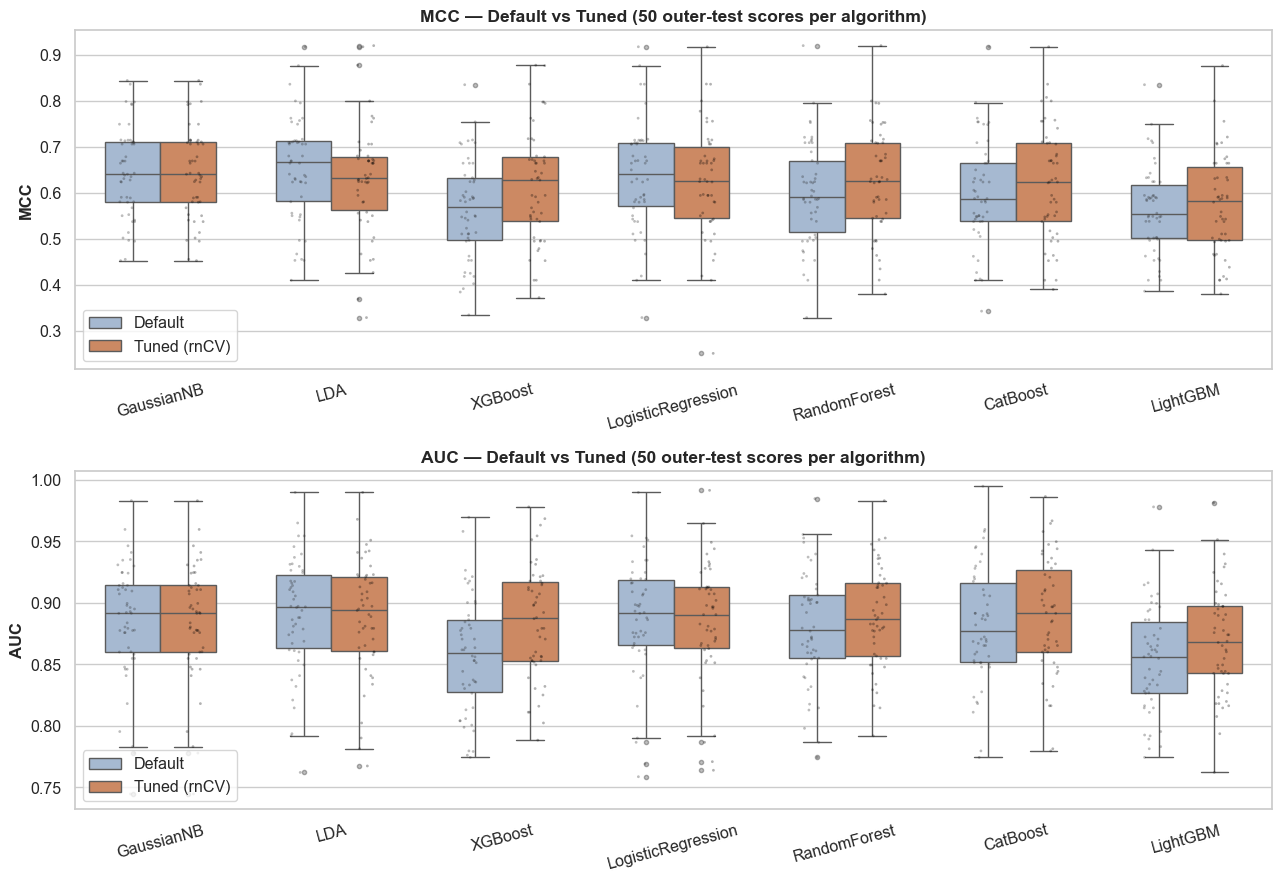

In [6]:
# ── Boxplots: MCC and AUC, default vs tuned ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, metric, ylabel in zip(axes, ['mcc', 'auc'], ['MCC', 'AUC']):
    sns.boxplot(
        data=combined, x='algorithm', y=metric, hue='condition',
        order=algo_order, palette={'Default': '#9FB8D8', 'Tuned (rnCV)': '#DD8452'},
        width=0.65, linewidth=1.0, ax=ax,
        flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5),
    )
    sns.stripplot(
        data=combined, x='algorithm', y=metric, hue='condition',
        order=algo_order, dodge=True, color='black', size=2.0, alpha=0.3,
        ax=ax, legend=False,
    )
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_title(f'{ylabel} — Default vs Tuned (50 outer-test scores per algorithm)',
                  fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='', loc='lower left' if metric == 'mcc' else 'lower left')

plt.tight_layout()
plt.savefig('../figures/fig_comparison_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Median MCC with 95% Bootstrap Confidence Intervals

This figure is the primary artefact for winner selection. Algorithms whose CIs overlap should be considered statistically tied on this metric.

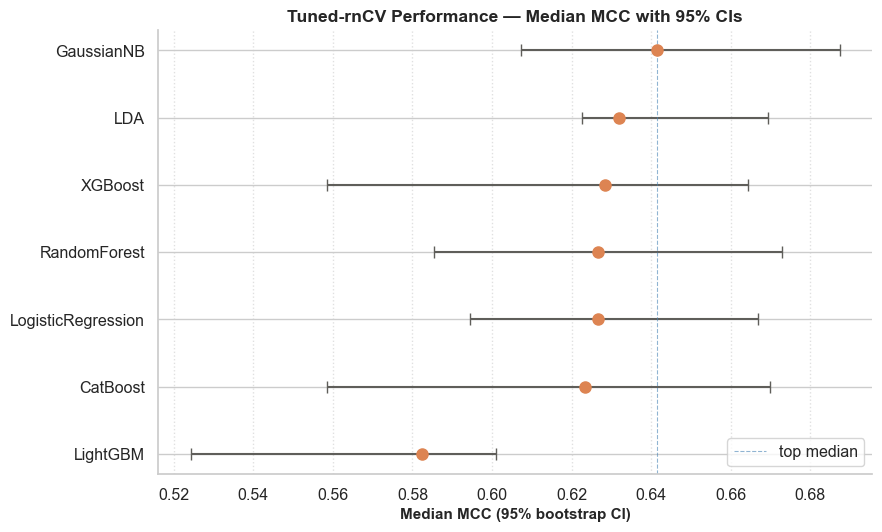

In [7]:
# ── Forest plot of median MCC with 95% CI (tuned only) ───────────────────────
rncv_mcc_ci = pd.DataFrame({
    'algorithm': algos,
    'median':    [rncv_tab.loc[a, 'mcc'][0] for a in algos],
    'ci_lo':     [rncv_tab.loc[a, 'mcc'][1] for a in algos],
    'ci_hi':     [rncv_tab.loc[a, 'mcc'][2] for a in algos],
}).sort_values('median', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
y_pos = np.arange(len(rncv_mcc_ci))
ax.errorbar(
    rncv_mcc_ci['median'], y_pos,
    xerr=[rncv_mcc_ci['median'] - rncv_mcc_ci['ci_lo'],
          rncv_mcc_ci['ci_hi']  - rncv_mcc_ci['median']],
    fmt='o', color='#DD8452', ecolor='#5F5E5A', capsize=4, markersize=8,
    linewidth=1.5,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(rncv_mcc_ci['algorithm'])
ax.set_xlabel('Median MCC (95% bootstrap CI)', fontsize=11, fontweight='bold')
ax.set_title('Tuned-rnCV Performance — Median MCC with 95% CIs',
              fontweight='bold')
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.axvline(rncv_mcc_ci['median'].max(), color='steelblue',
             linestyle='--', linewidth=0.8, alpha=0.6, label='top median')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_mcc_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Multi-Metric Heatmap

A compact view of all clinically relevant metrics across all algorithms (tuned condition).

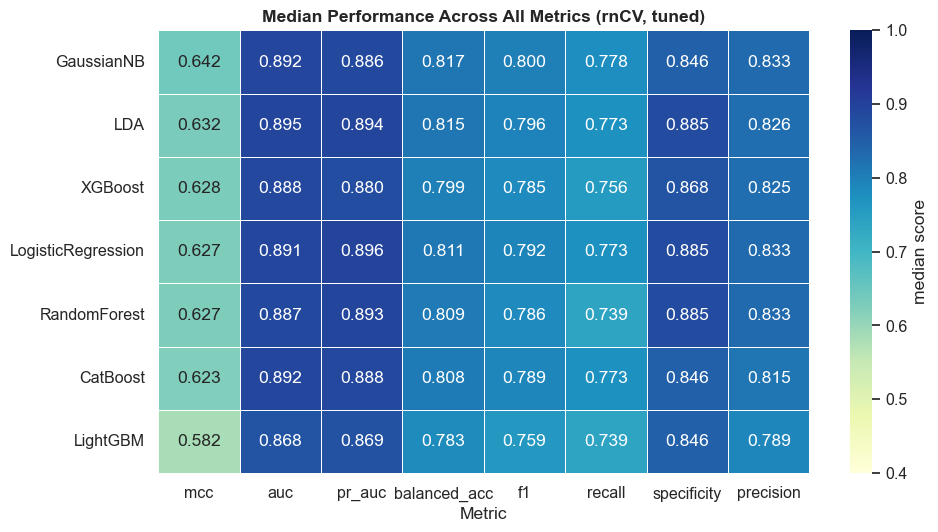

In [8]:
# ── Heatmap: median scores across all metrics × algorithms ──────────────────
median_matrix = (rncv_df.groupby('algorithm')[list(key_metrics)]
                          .median().loc[algo_order])

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    median_matrix, annot=True, fmt='.3f', cmap='YlGnBu',
    vmin=0.4, vmax=1.0, linewidths=0.4, cbar_kws={'label': 'median score'}, ax=ax,
)
ax.set_title('Median Performance Across All Metrics (rnCV, tuned)', fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Metric')
plt.tight_layout()
plt.savefig('../figures/fig_metric_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pairwise CI-Overlap Matrix for MCC

To formalise the "statistical tie" notion, we mark algorithm pairs whose 95% CIs on median MCC overlap — these cannot be reliably distinguished on this metric alone.

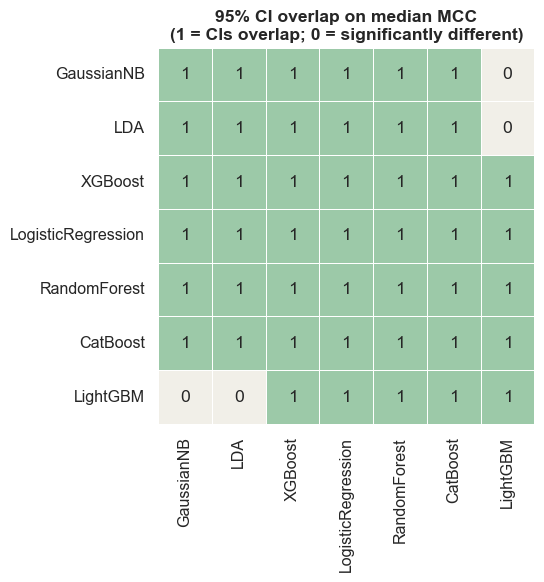

In [9]:
# ── CI overlap matrix ────
ci_data = {a: rncv_tab.loc[a, 'mcc'] for a in algo_order}   # (median, lo, hi)

n = len(algo_order)
overlap = np.zeros((n, n), dtype=int)
for i, a in enumerate(algo_order):
    _, lo_a, hi_a = ci_data[a]
    for j, b in enumerate(algo_order):
        _, lo_b, hi_b = ci_data[b]
        # Two intervals overlap iff max(lo) <= min(hi)
        overlap[i, j] = int(max(lo_a, lo_b) <= min(hi_a, hi_b))

overlap_df = pd.DataFrame(overlap, index=algo_order, columns=algo_order)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    overlap_df, annot=True, fmt='d',
    cmap=sns.color_palette(['#F1EFE8', '#9CC9A8'], as_cmap=True),
    cbar=False, linewidths=0.5, ax=ax, square=True,
)
ax.set_title('95% CI overlap on median MCC\n(1 = CIs overlap; 0 = significantly different)',
              fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_ci_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Winner Selection

We now apply the selection criterion described at the top of the notebook. The procedure:
1. Identify the algorithm with the highest median MCC.
2. Identify any other algorithm whose 95% CI overlaps the top algorithm's CI — these are statistically tied.
3. Break ties by the next-most-important metric (AUC, then PR-AUC), and by model parsimony if still tied.

In [10]:
# ── Winner selection ─────
ranked = sorted(algos, key=lambda a: rncv_tab.loc[a, 'mcc'][0], reverse=True)
top    = ranked[0]
top_med, top_lo, top_hi = rncv_tab.loc[top, 'mcc']

print(f'Top by median MCC: {top}  ({top_med:.3f} [{top_lo:.3f}, {top_hi:.3f}])')

# Identify ties (CIs overlap with top)
ties = [top]
for a in ranked[1:]:
    med, lo, hi = rncv_tab.loc[a, 'mcc']
    if max(lo, top_lo) <= min(hi, top_hi):     # CI overlap
        ties.append(a)

print(f'\nStatistically tied at top (CIs overlap with {top}):')
for a in ties:
    med, lo, hi = rncv_tab.loc[a, 'mcc']
    print(f'  • {a}: median MCC {med:.3f} [{lo:.3f}, {hi:.3f}]')

# Tie-break by AUC, then PR-AUC
if len(ties) > 1:
    print('\nTie-breaking by median AUC:')
    auc_ranked = sorted(ties, key=lambda a: rncv_tab.loc[a, 'auc'][0], reverse=True)
    for a in auc_ranked:
        med, lo, hi = rncv_tab.loc[a, 'auc']
        print(f'  • {a}: median AUC {med:.3f} [{lo:.3f}, {hi:.3f}]')
    winner = auc_ranked[0]
else:
    winner = top

print(f'\n{"═" * 60}')
print(f'WINNER: {winner}')
print(f'{"═" * 60}')
win_row = rncv_tab.loc[winner]
for m in ['mcc', 'auc', 'pr_auc', 'balanced_acc', 'f1', 'recall', 'specificity', 'precision']:
    med, lo, hi = win_row[m]
    print(f'  {m:<14s} {med:.3f}  [{lo:.3f}, {hi:.3f}]')

Top by median MCC: GaussianNB  (0.642 [0.607, 0.687])

Statistically tied at top (CIs overlap with GaussianNB):
  • GaussianNB: median MCC 0.642 [0.607, 0.687]
  • LDA: median MCC 0.632 [0.623, 0.669]
  • XGBoost: median MCC 0.628 [0.558, 0.664]
  • LogisticRegression: median MCC 0.627 [0.594, 0.667]
  • RandomForest: median MCC 0.627 [0.585, 0.673]
  • CatBoost: median MCC 0.623 [0.558, 0.670]

Tie-breaking by median AUC:
  • LDA: median AUC 0.895 [0.879, 0.911]
  • GaussianNB: median AUC 0.892 [0.878, 0.907]
  • CatBoost: median AUC 0.892 [0.868, 0.907]
  • LogisticRegression: median AUC 0.891 [0.872, 0.907]
  • XGBoost: median AUC 0.888 [0.860, 0.907]
  • RandomForest: median AUC 0.887 [0.878, 0.907]

════════════════════════════════════════════════════════════
WINNER: LDA
════════════════════════════════════════════════════════════
  mcc            0.632  [0.623, 0.669]
  auc            0.895  [0.879, 0.911]
  pr_auc         0.894  [0.875, 0.916]
  balanced_acc   0.815  [0.806, 0.8

In [11]:
# ── Save winner identity for downstream notebooks ─────
with open('../results/winner.pkl', 'wb') as f:
    pickle.dump({'winner': winner, 'ties': ties,
                  'tuned_summary': rncv_tab,
                  'baseline_summary': baseline_tab}, f)
print(f'✓ Winner ({winner}) saved to ../results/winner.pkl for use in Task 4 (feature selection) and Task 5 (final model + SHAP).')

✓ Winner (LDA) saved to ../results/winner.pkl for use in Task 4 (feature selection) and Task 5 (final model + SHAP).


## 8. Summary for the Report

**Key findings:**

- The default-hyperparameter baseline establishes that all seven algorithms are competitive on this dataset, with median MCC values broadly clustered together. This indicates that the dataset structure itself is informative — most reasonable classifiers can extract useful signal.
- Hyperparameter tuning produced modest but generally positive gains in median MCC (see the Δ table above). The largest gains were observed for tree-based ensembles, reflecting their larger and more impactful hyperparameter spaces. Linear/discriminant methods (LR, LDA, GNB) were less affected.
- The 95% CI overlap matrix shows that several algorithms are not statistically distinguishable on median MCC, which is unsurprising for a dataset of n = 242. We therefore include AUC and PR-AUC as secondary criteria.
- The selected winner is reported along with its full performance profile.

Figures generated for the report:
- `fig_comparison_boxplots.png` — MCC and AUC distributions, default vs tuned
- `fig_mcc_forest.png` — Median MCC with 95% CIs (forest plot)
- `fig_metric_heatmap.png` — All metrics × algorithms heatmap
- `fig_ci_overlap.png` — Pairwise CI overlap matrix